In [1]:
pip install tensorflow==2.12.0 mediapipe==0.10.9 opencv-python numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\asiddiqui\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [5]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [6]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [7]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [8]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [9]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [24]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [11]:
draw_landmarks(frame, results)

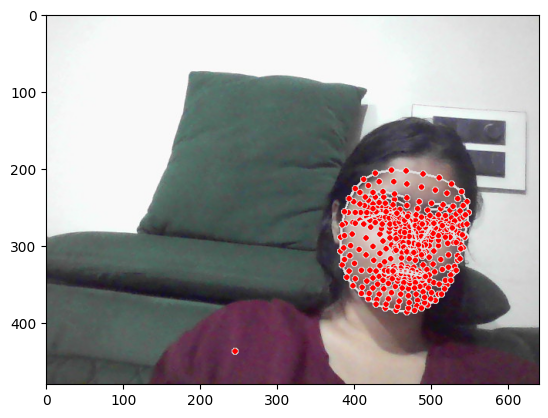

In [12]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [13]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [14]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [15]:
if results.face_landmarks:
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten()
else:
    face = np.zeros(1404)

In [16]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [17]:
result_test = extract_keypoints(results)

In [18]:
result_test

array([ 0.75601482,  0.62489486, -1.35699046, ...,  0.        ,
        0.        ,  0.        ])

In [19]:
np.save('0', result_test)

In [20]:
np.load('0.npy')

array([ 0.75601482,  0.62489486, -1.35699046, ...,  0.        ,
        0.        ,  0.        ])

In [21]:
os.path

<module 'ntpath' from 'c:\\Users\\asiddiqui\\AppData\\Local\\Programs\\Python\\Python310\\lib\\ntpath.py'>

In [22]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['Good Morning', 'Good Afternoon', 'Good Evening', 'Good Night', 'Hello', 'I am not worried', 'I understand', ' I dont understand', 'I dont know', 'I know'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

In [23]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [25]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
#                 print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [23]:
cap.release()
cv2.destroyAllWindows()

In [26]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [27]:
label_map = {label:num for num, label in enumerate(actions)}
label_map

{'Good Morning': 0,
 'Good Afternoon': 1,
 'Good Evening': 2,
 'Good Night': 3,
 'Hello': 4,
 'I am not worried': 5,
 'I understand': 6,
 ' I dont understand': 7,
 'I dont know': 8,
 'I know': 9}

In [28]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [29]:
np.array(sequences).shape

(300, 30, 1662)

In [30]:
np.array(labels).shape

(300,)

In [31]:
X = np.array(sequences)

In [32]:
X.shape

(300, 30, 1662)

In [33]:
y = to_categorical(labels).astype(int)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [35]:
y_test.shape

(15, 10)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard


In [38]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [76]:
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
lstm_model.add(LSTM(128, return_sequences=True, activation='relu'))
lstm_model.add(LSTM(64, return_sequences=False, activation='relu'))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(actions.shape[0], activation='softmax'))

lstm_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
lstm_history = lstm_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])


Epoch 1/260
9/9 [==============================] - 4s 126ms/step - loss: 2.6826 - categorical_accuracy: 0.0807 - val_loss: 2.3453 - val_categorical_accuracy: 0.2000
Epoch 2/260
9/9 [==============================] - 1s 98ms/step - loss: 2.3076 - categorical_accuracy: 0.1544 - val_loss: 2.3292 - val_categorical_accuracy: 0.0667
Epoch 3/260
9/9 [==============================] - 1s 104ms/step - loss: 2.3535 - categorical_accuracy: 0.2105 - val_loss: 2.0478 - val_categorical_accuracy: 0.2000
Epoch 4/260
9/9 [==============================] - 1s 98ms/step - loss: 2.1693 - categorical_accuracy: 0.0947 - val_loss: 1.8257 - val_categorical_accuracy: 0.2000
Epoch 5/260
9/9 [==============================] - 1s 97ms/step - loss: 2.1433 - categorical_accuracy: 0.2105 - val_loss: 2.2774 - val_categorical_accuracy: 0.0000e+00
Epoch 6/260
9/9 [==============================] - 1s 106ms/step - loss: 2.2260 - categorical_accuracy: 0.1754 - val_loss: 1.7689 - val_categorical_accuracy: 0.2667
Epoch 7/2

In [80]:
lstm_model.summary()
lstm_res = lstm_model.predict(X_test)
print(actions[np.argmax(lstm_res[0])], actions[np.argmax(y_test[0])])

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_12 (LSTM)              (None, 30, 64)            442112    
                                                                 
 lstm_13 (LSTM)              (None, 30, 128)           98816     
                                                                 
 lstm_14 (LSTM)              (None, 64)                49408     
                                                                 
 dense_36 (Dense)            (None, 64)                4160      
                                                                 
 dense_37 (Dense)            (None, 32)                2080      
                                                                 
 dense_38 (Dense)            (None, 10)                330       
                                                                 
Total params: 596,906
Trainable params: 596,906
Non-tr

In [81]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = lstm_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 37ms/step


0.9333333333333333

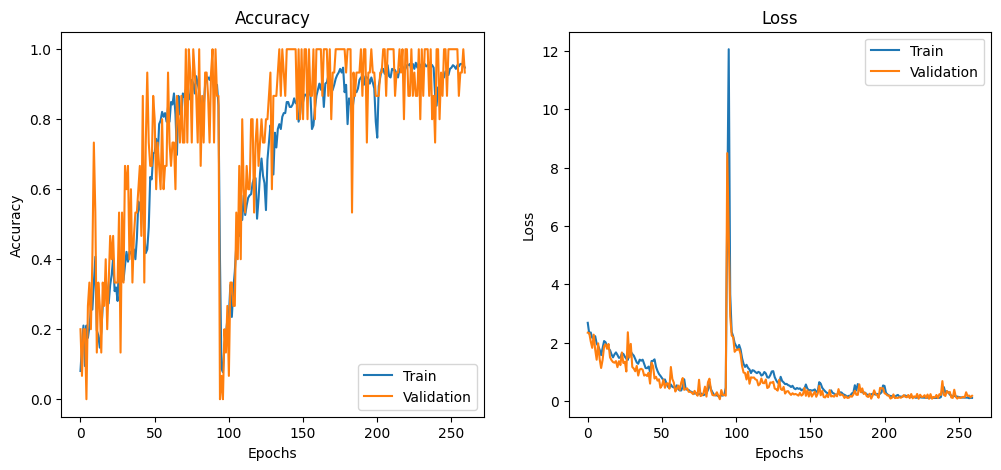

In [82]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(lstm_history.history['categorical_accuracy'])
plt.plot(lstm_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [83]:
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(64, return_sequences=True, activation='relu', input_shape=(30,1662)),
    GRU(128, return_sequences=True, activation='relu'),
    GRU(64, return_sequences=False, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(actions.shape[0], activation='softmax')
])

gru_model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

gru_history = gru_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])
gru_model.summary()

Epoch 1/260
9/9 [==============================] - 5s 125ms/step - loss: 2.3056 - categorical_accuracy: 0.0807 - val_loss: 2.2826 - val_categorical_accuracy: 0.0667
Epoch 2/260
9/9 [==============================] - 1s 81ms/step - loss: 2.2004 - categorical_accuracy: 0.1965 - val_loss: 2.0753 - val_categorical_accuracy: 0.1333
Epoch 3/260
9/9 [==============================] - 1s 88ms/step - loss: 1.9877 - categorical_accuracy: 0.2561 - val_loss: 1.7821 - val_categorical_accuracy: 0.4000
Epoch 4/260
9/9 [==============================] - 1s 97ms/step - loss: 1.8434 - categorical_accuracy: 0.2596 - val_loss: 1.4923 - val_categorical_accuracy: 0.4667
Epoch 5/260
9/9 [==============================] - 1s 112ms/step - loss: 1.7316 - categorical_accuracy: 0.2667 - val_loss: 1.4780 - val_categorical_accuracy: 0.5333
Epoch 6/260
9/9 [==============================] - 1s 99ms/step - loss: 1.5487 - categorical_accuracy: 0.4386 - val_loss: 1.1115 - val_categorical_accuracy: 0.6667
Epoch 7/260
9/

In [84]:
gru_res = gru_model.predict(X_test)
print(actions[np.argmax(gru_res[0])], actions[np.argmax(y_test[0])])

1/1 [==============================] - 0s 407ms/step
Hello Hello


In [85]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = gru_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 33ms/step


1.0

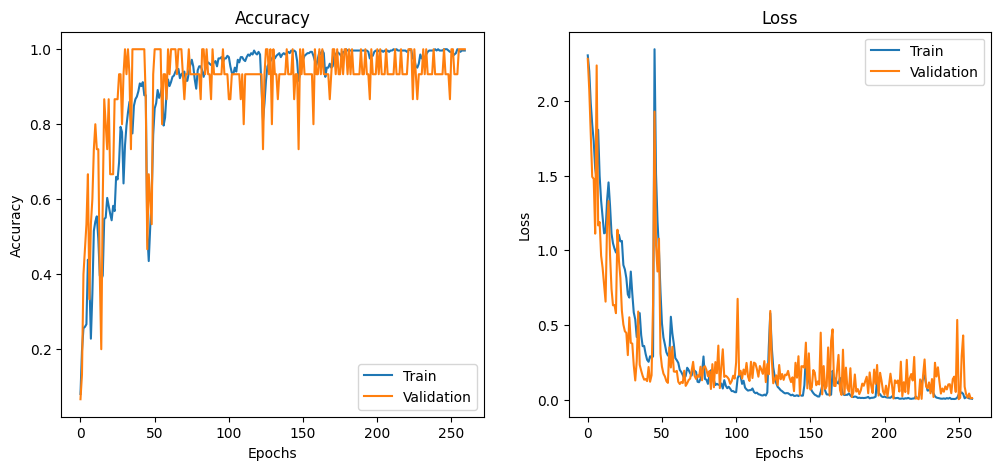

In [86]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(gru_history.history['categorical_accuracy'])
plt.plot(gru_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(gru_history.history['loss'])
plt.plot(gru_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [87]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(30,1662)),
    MaxPooling1D(2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(actions.shape[0], activation='softmax')
])

cnn_model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

cnn_history = cnn_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])
cnn_model.summary()

Epoch 1/260
9/9 [==============================] - 1s 76ms/step - loss: 2.3376 - categorical_accuracy: 0.1298 - val_loss: 2.2911 - val_categorical_accuracy: 0.0000e+00
Epoch 2/260
9/9 [==============================] - 0s 40ms/step - loss: 2.3065 - categorical_accuracy: 0.0947 - val_loss: 2.2471 - val_categorical_accuracy: 0.3333
Epoch 3/260
9/9 [==============================] - 0s 29ms/step - loss: 2.2559 - categorical_accuracy: 0.1614 - val_loss: 2.1668 - val_categorical_accuracy: 0.4667
Epoch 4/260
9/9 [==============================] - 0s 31ms/step - loss: 2.1827 - categorical_accuracy: 0.2000 - val_loss: 2.0337 - val_categorical_accuracy: 0.2667
Epoch 5/260
9/9 [==============================] - 0s 34ms/step - loss: 2.1297 - categorical_accuracy: 0.2035 - val_loss: 1.8855 - val_categorical_accuracy: 0.2667
Epoch 6/260
9/9 [==============================] - 0s 30ms/step - loss: 2.0761 - categorical_accuracy: 0.2035 - val_loss: 1.9097 - val_categorical_accuracy: 0.3333
Epoch 7/260


In [88]:
cnn_res = cnn_model.predict(X_test)
print(actions[np.argmax(cnn_res[0])], actions[np.argmax(y_test[0])])

1/1 [==============================] - 0s 77ms/step
Hello Hello


In [89]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = cnn_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 16ms/step


1.0

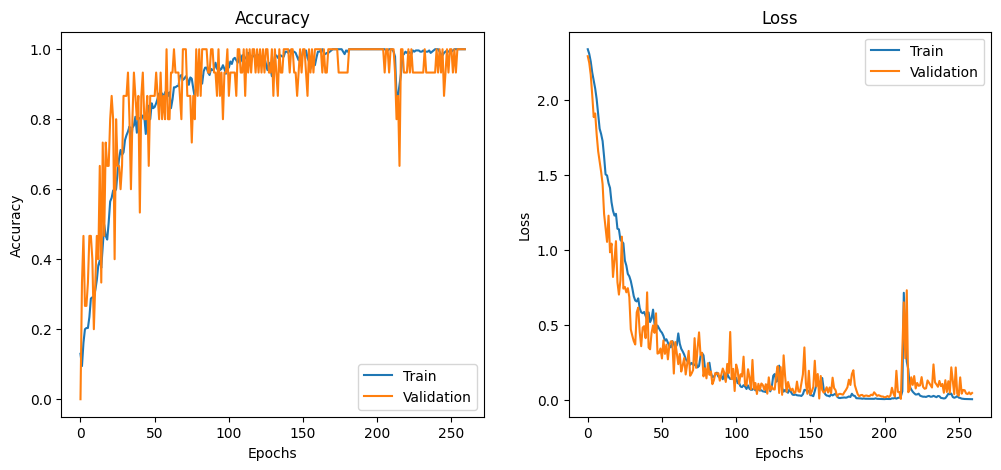

In [90]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_history.history['categorical_accuracy'])
plt.plot(cnn_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [91]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization,
    MultiHeadAttention, Dropout,
    GlobalAveragePooling1D, Embedding, Add
)
from tensorflow.keras.models import Model


# Positional Encoding
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_emb = Embedding(seq_len, d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        return x + self.pos_emb(positions)


inputs = Input(shape=(30, 1662))
x = Dense(128)(inputs)          # reduce dimension first
x = PositionalEmbedding(30, 128)(x)

attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = Add()([x, attn])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(actions.shape[0], activation='softmax')(x)

transformer_model = Model(inputs, outputs)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

transformer_history = transformer_model.fit(X_train, y_train, epochs=260, validation_data=(X_test, y_test), callbacks=[tb_callback])
transformer_model.summary()

Epoch 1/260
9/9 [==============================] - 2s 57ms/step - loss: 2.3132 - categorical_accuracy: 0.0877 - val_loss: 2.2153 - val_categorical_accuracy: 0.1333
Epoch 2/260
9/9 [==============================] - 0s 31ms/step - loss: 2.1671 - categorical_accuracy: 0.1789 - val_loss: 2.1890 - val_categorical_accuracy: 0.0000e+00
Epoch 3/260
9/9 [==============================] - 0s 29ms/step - loss: 2.0966 - categorical_accuracy: 0.2211 - val_loss: 1.9802 - val_categorical_accuracy: 0.2000
Epoch 4/260
9/9 [==============================] - 0s 30ms/step - loss: 2.0212 - categorical_accuracy: 0.3088 - val_loss: 1.8704 - val_categorical_accuracy: 0.4000
Epoch 5/260
9/9 [==============================] - 0s 31ms/step - loss: 1.9581 - categorical_accuracy: 0.2596 - val_loss: 1.8512 - val_categorical_accuracy: 0.2000
Epoch 6/260
9/9 [==============================] - 0s 30ms/step - loss: 1.8829 - categorical_accuracy: 0.3298 - val_loss: 1.7004 - val_categorical_accuracy: 0.5333
Epoch 7/260


In [92]:
transformer_res = transformer_model.predict(X_test)
print(actions[np.argmax(transformer_res[0])], actions[np.argmax(y_test[0])])

1/1 [==============================] - 0s 133ms/step
Hello Hello


In [93]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = transformer_model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
multilabel_confusion_matrix(ytrue, yhat)
accuracy_score(ytrue, yhat)

1/1 [==============================] - 0s 13ms/step


1.0

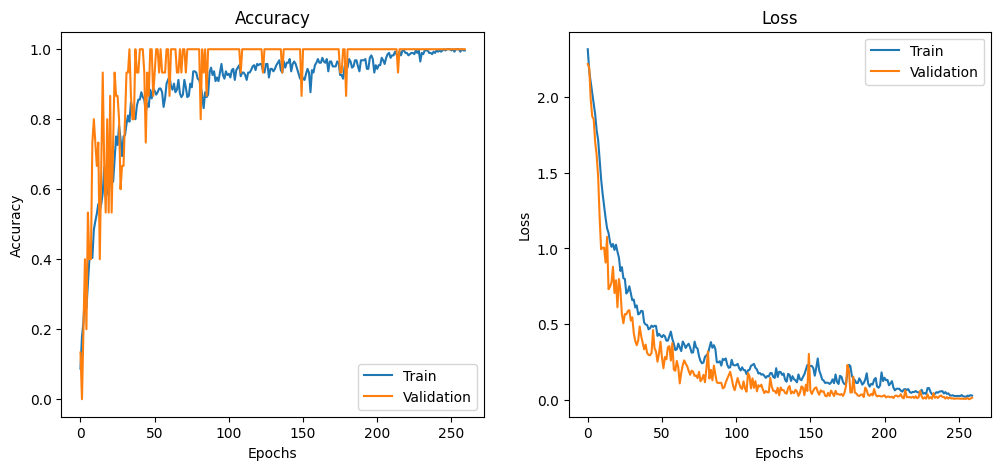

In [94]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(transformer_history.history['categorical_accuracy'])
plt.plot(transformer_history.history['val_categorical_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(transformer_history.history['loss'])
plt.plot(transformer_history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

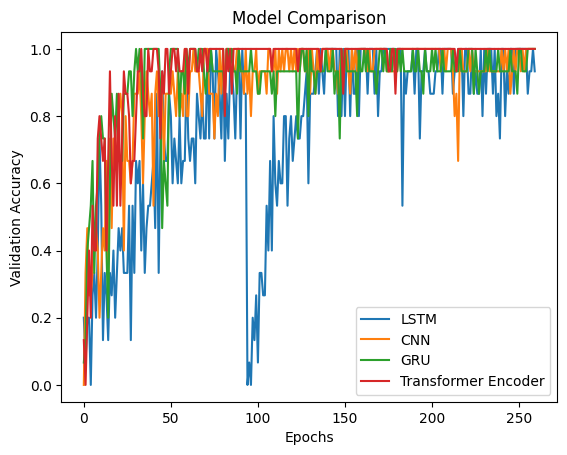

In [95]:
histories = {
    "LSTM": lstm_history,
    "CNN": cnn_history,
    "GRU": gru_history,
    "Transformer Encoder": transformer_history
    
}

plt.figure()
for name, hist in histories.items():
    plt.plot(hist.history['val_categorical_accuracy'], label=name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison')
plt.legend()
plt.show()

In [96]:
lstm_model.save('lstm_isl.h5')
cnn_model.save('cnn_isl.h5')
gru_model.save('gru_isl.h5')
transformer_model.save('transformer_isl.h5')

In [97]:
lstm_model.load_weights('lstm_isl.h5')
cnn_model.load_weights('cnn_isl.h5')
gru_model.load_weights('gru_isl.h5')
transformer_model.load_weights('transformer_isl.h5')

In [98]:
from scipy import stats

In [99]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame
plt.figure(figsize=(18,18))

<Figure size 1800x1800 with 0 Axes>

<Figure size 1800x1800 with 0 Axes>

In [100]:
plt.imshow(prob_viz(res, actions, image, colors))

IndexError: list index out of range

In [ ]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = lstm_model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()